In [1]:
import sys

sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

large_data_dir = gf_utils.large_data_dir

In [ ]:
gf_dir = large_data_dir + 'gf_CL3_HB_Standard/BC1_giftwrap/'
adata_path = large_data_dir + 'CL3_HB_Standard.h5ad'

probe_reads_cl = gf_utils.get_input_probe_reads(gf_dir, read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path, collapse_across_probes=True)
probe_reads_cl_original = probe_reads_cl.copy()

10833721 UMIs found
Collapsing UMIs across probes, 10833721 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 10802957 UMIs remaining (99.72%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 8986489 UMIs remaining (82.95%)


In [3]:
expected_genotypes_file = '../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv'
expected_genotypes = pd.read_csv(expected_genotypes_file, index_col=0)

### remove heterozygous calls for this analysis
expected_genotypes = expected_genotypes[expected_genotypes['genotype_from_bulk'] != 'heterozygous']
expected_genotypes.loc[expected_genotypes['genotype_from_bulk'] == 'homozygous_ref','expected_gapfill'] = expected_genotypes.loc[expected_genotypes['genotype_from_bulk'] == 'homozygous_ref','gapfill_from_transcriptome']
expected_genotypes.loc[expected_genotypes['genotype_from_bulk'] == 'homozygous_alt','expected_gapfill'] = expected_genotypes.loc[expected_genotypes['genotype_from_bulk'] == 'homozygous_alt','gap_probe_sequence']
expected_genotypes = expected_genotypes[['cell_type','probe_idx','expected_gapfill']].dropna().copy()

In [4]:
probe_reads_cl = gf_utils.add_expected_gapfills_for_pcr_swap_likelihood(expected_genotypes, probe_reads_cl)
x,likelihoods = gf_utils.get_likelihood_list(probe_reads_cl,min_size=2000)
prob_real = gf_utils.get_swap_probabilities(probe_reads_cl,probe_reads_cl,x,likelihoods,plot=False)


number of probes to use: 14


In [5]:
df = pd.DataFrame(likelihoods, index=x, columns=['likelihoods'])
df['prob_real'] = df.index.map(prob_real.to_dict())
df['fraction_correct'] = df['likelihoods'].copy()
df['fraction_incorrect'] = (1 - df['likelihoods'])

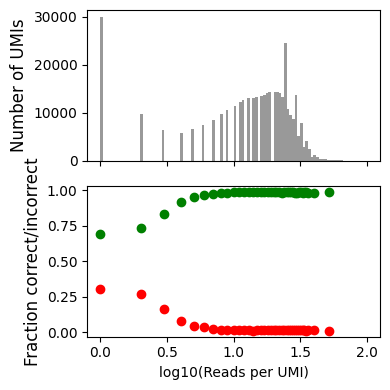

In [6]:
fig,(ax1,ax2) = plt.subplots(figsize=(4,2*2),nrows=2, sharex=True)
hist = ax1.hist(np.log10(probe_reads_cl['pcr_duplicate_count']),bins=100,alpha=0.8,density=False, color = 'grey')
ax1.set_ylabel('Number of UMIs', size=12)

ax2.scatter(np.log10(df.index),df['fraction_correct'], color = 'green')
ax2.scatter(np.log10(df.index),df['fraction_incorrect'], color = 'red')
ax2.set_ylabel('Fraction correct/incorrect', size=12)

ymin, ymax = -0.03,1.03
ax2.set_ylim(ymin, ymax)

ax2.set_xlabel('log10(Reads per UMI)')
plt.tight_layout()

plt.savefig('../plots/example_fraction_correct.pdf')

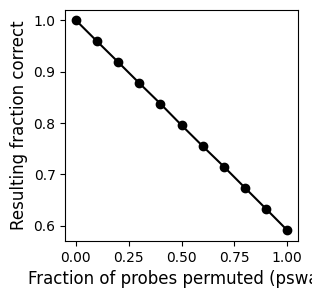

In [7]:
frac_correct = {}
for ratio in np.arange(0, 1.1, 0.1):
    frac_correct[ratio] = gf_utils.permute_gapfills(probe_reads_cl, ratio)
frac_correct = pd.DataFrame(frac_correct, index=[0]).T

fig,ax = plt.subplots(figsize=(3,3))
ax.plot(frac_correct.index, frac_correct[0], color='k', marker='o')
ax.set_xlabel('Fraction of probes permuted (pswap)', size=12)
ax.set_ylabel('Resulting fraction correct', size=12)

plt.savefig('../plots/pswap_to_fraction_correct.pdf')

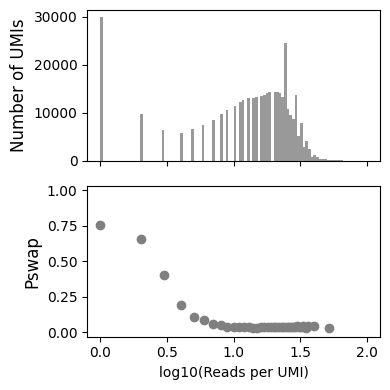

In [8]:
fig,(ax1,ax2) = plt.subplots(figsize=(4,2*2),nrows=2, sharex=True)
hist = ax1.hist(np.log10(probe_reads_cl['pcr_duplicate_count']),bins=100,alpha=0.8,density=False, color = 'grey')
ax1.set_ylabel('Number of UMIs', size=12)

coefficients = np.polyfit(df.dropna()['likelihoods'], df.dropna()['prob_real'], 1)
fitted_prob_real = coefficients[0] * df['likelihoods'] + coefficients[1]
ax2.scatter(np.log10(df.index), 1-fitted_prob_real, color='grey')
ax2.set_ylabel('Pswap', size=12)
ax2.set_xlabel('log10(Reads per UMI)')

ax2.set_ylim(-0.03,1.03)

plt.tight_layout()

plt.savefig('../plots/pswap_vs_read_count.pdf')

In [ ]:
### now show downsampling for a patient

probe_reads_cl = probe_reads_cl_original.copy()
cl_min_threshold = 2 ## min_threshold is an inclusive threshold above obvious background

BC = 'BC001'

gf_dirs = {}

adata_path = large_data_dir + 'MPN_WTA/MPN_1plex_' + BC + '_genotyped.h5ad' ### this would usually be h5ad without genotypes
gf_dir = large_data_dir + 'gf_MPN/MPN_1plex/BC' + str(int(BC.replace('BC',''))) + '_giftwrap/'

min_percent_supporting = 0.9
collapse_across_probes = True

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 0, cell_barcode_suffix='-0', adata_path = adata_path, min_percent_supporting=min_percent_supporting, collapse_across_probes=collapse_across_probes)
probe_reads_patient = probe_reads.copy()

### save pcr swap likelihoods #####
patient_min_threshold = 1 ## min_threshold is an inclusive read threshold above obvious background



12317 UMIs found
Collapsing UMIs across probes, 12317 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 12300 UMIs remaining (99.86%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 10819 UMIs remaining (87.84%)


In [10]:
### sample the cell line distribution and get probability of pcr swaps for the patient

kl_patient = gf_utils.get_knee(probe_reads_patient, min_threshold = np.log10(patient_min_threshold)) ## min_threshold is an inclusive threshold above obvious background
kl_cl = gf_utils.get_knee(probe_reads_cl, min_threshold = np.log10(cl_min_threshold)) ## min_threshold is an inclusive threshold above obvious background
probe_reads_cl_sampled = gf_utils.sample_reference_probe_reads(probe_reads_cl, (10**kl_patient.knee_y)/ (10**kl_cl.knee_y), plot=False, comparator_probe_reads=probe_reads_patient)

probe_reads_cl_sampled = gf_utils.add_expected_gapfills_for_pcr_swap_likelihood(expected_genotypes, probe_reads_cl_sampled)
x,likelihoods = gf_utils.get_likelihood_list(probe_reads_cl_sampled,min_size=2000)
prob_real = gf_utils.get_swap_probabilities(probe_reads_patient,probe_reads_cl_sampled,x,likelihoods,plot=False)


number of probes to use: 14


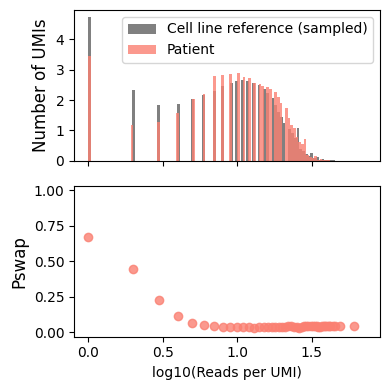

In [11]:
fig,(ax1,ax2) = plt.subplots(figsize=(4,2*2),nrows=2, sharex=True)
hist = ax1.hist(np.log10(probe_reads_cl_sampled['pcr_duplicate_count']),bins=100,alpha=1, density=True, label='Cell line reference (sampled)', color = 'grey')
hist = ax1.hist(np.log10(probe_reads_patient['pcr_duplicate_count']),bins=100,density=True, alpha=0.8, label='Patient', color = 'salmon')
ax1.legend()
ax1.set_ylabel('Number of UMIs', size=12)

ax2.scatter(np.log10(prob_real.index),1-prob_real, color = 'salmon', alpha=0.8)
ax2.set_ylabel('Pswap', size=12)

ymin, ymax = -0.03, 1.03
ax2.set_ylim(ymin, ymax)

ax2.set_xlabel('log10(Reads per UMI)')
plt.tight_layout()

plt.savefig('../plots/example_patient_downsample_and_likelihood.pdf')